### Results
The simple linear model functions well on the random samples which are scored high but absolutely fails on the artifficial samples that should be labeled as anomalous

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import torch 

In [23]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [25]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

In [26]:
from anomaly_detection.config.paths import CHECKPOINT_DIR
from anomaly_detection.models.lin_ae import LinAutoencoder

checkpoint = torch.load(f"{CHECKPOINT_DIR}/lin_autoenc_v1.pth", map_location="cpu")

config = checkpoint["config"]

model = LinAutoencoder()
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

LinAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=96, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Sigmoid()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=96, bias=True)
    (5): Sigmoid()
  )
)

In [37]:
type(full_dataset)

torch.Tensor

In [27]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Model consists of", trainable_params, "trainable parameters.")

Model consists of 17712 trainable parameters.


In [28]:
from anomaly_detection.utils.test_and_eval import get_outliers

outs = get_outliers(full_dataset)

In [ ]:
def score_points(pts, criterion=None):
    if not criterion:
        import torch
        criterion = torch.nn.MSELoss()

    out_scores = []
    for out in pts:
        pred = model(out).detach()
        loss = criterion(pred, out).detach().numpy()
        out_scores.append(loss)
        
    return out_scores

In [39]:
import torch.nn as nn

criterion = nn.MSELoss()
scores = score_points(full_dataset, criterion)

torch.Size([96])


In [31]:
out_scores = score_points(outs, criterion)

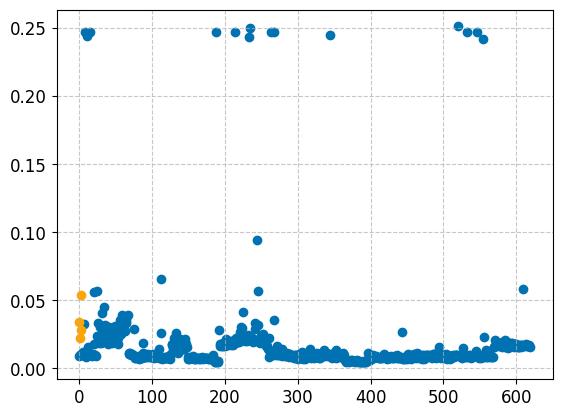

In [32]:
from anomaly_detection.utils.plotting_styles import apply_global_style

apply_global_style()
plt.scatter(range(len(scores)), scores)
plt.scatter(range(len(out_scores)), out_scores, color='orange')
plt.show()

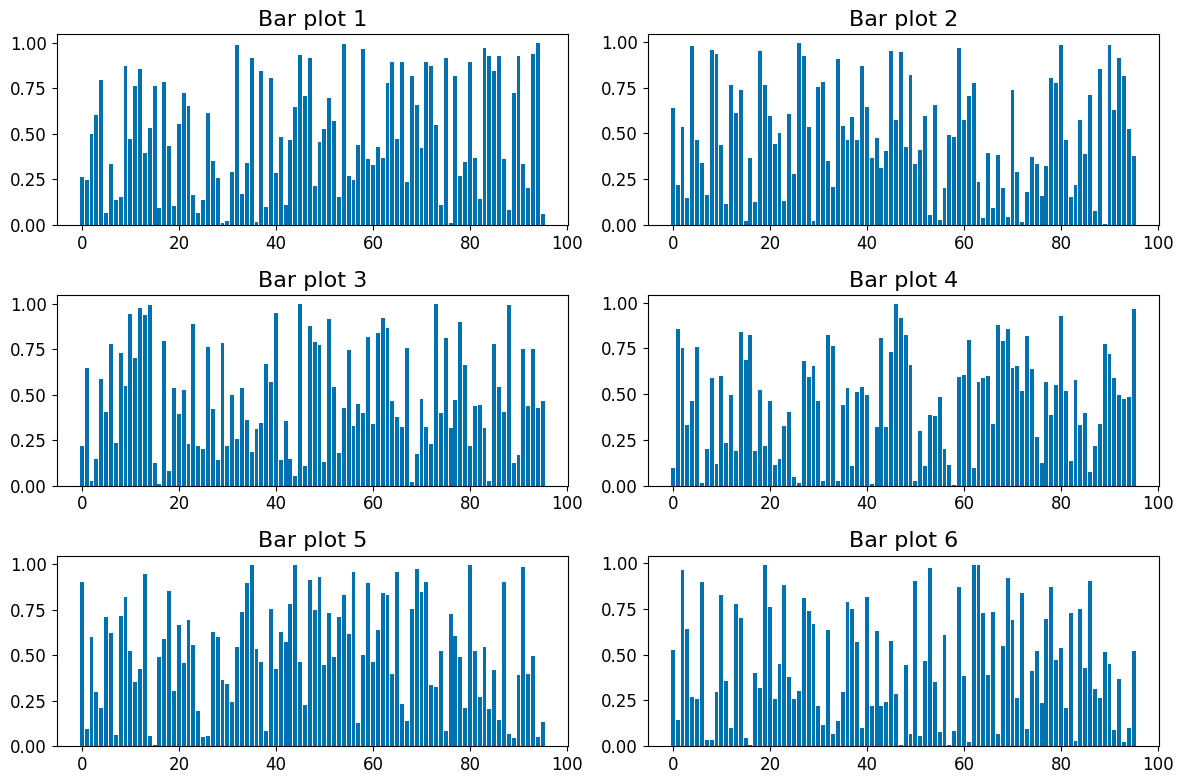

In [33]:
randoms = [torch.rand(96) for _ in range(6)]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (ax, data) in enumerate(zip(axes, randoms)):
    ax.bar(range(len(data)), data)
    ax.set_title(f"Bar plot {i+1}")

plt.tight_layout()
plt.show()

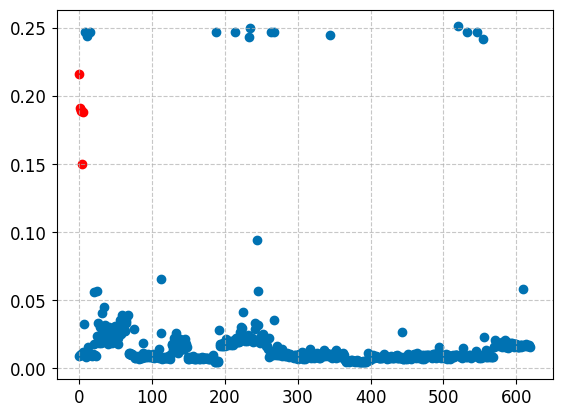

In [36]:
rand_scores = score_points(randoms)
apply_global_style()
plt.scatter(range(len(scores)), scores)
plt.scatter(range(len(rand_scores)), rand_scores, color='red')
plt.show()